<a href="https://colab.research.google.com/github/anujithesh26-del/SIH-2026-AI-ML-ENABLED-SEAMLESS-NAVIGATION/blob/testing/SIH_Only_PHONE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload your IO-VNBD phone-side CSV file (S-*.csv).


Saving S-S3a.csv to S-S3a (2).csv
Uploaded file: S-S3a (2).csv

Window: 100s to 150s (50s duration)
Final position error vs GPS ground truth: 198.3 meters


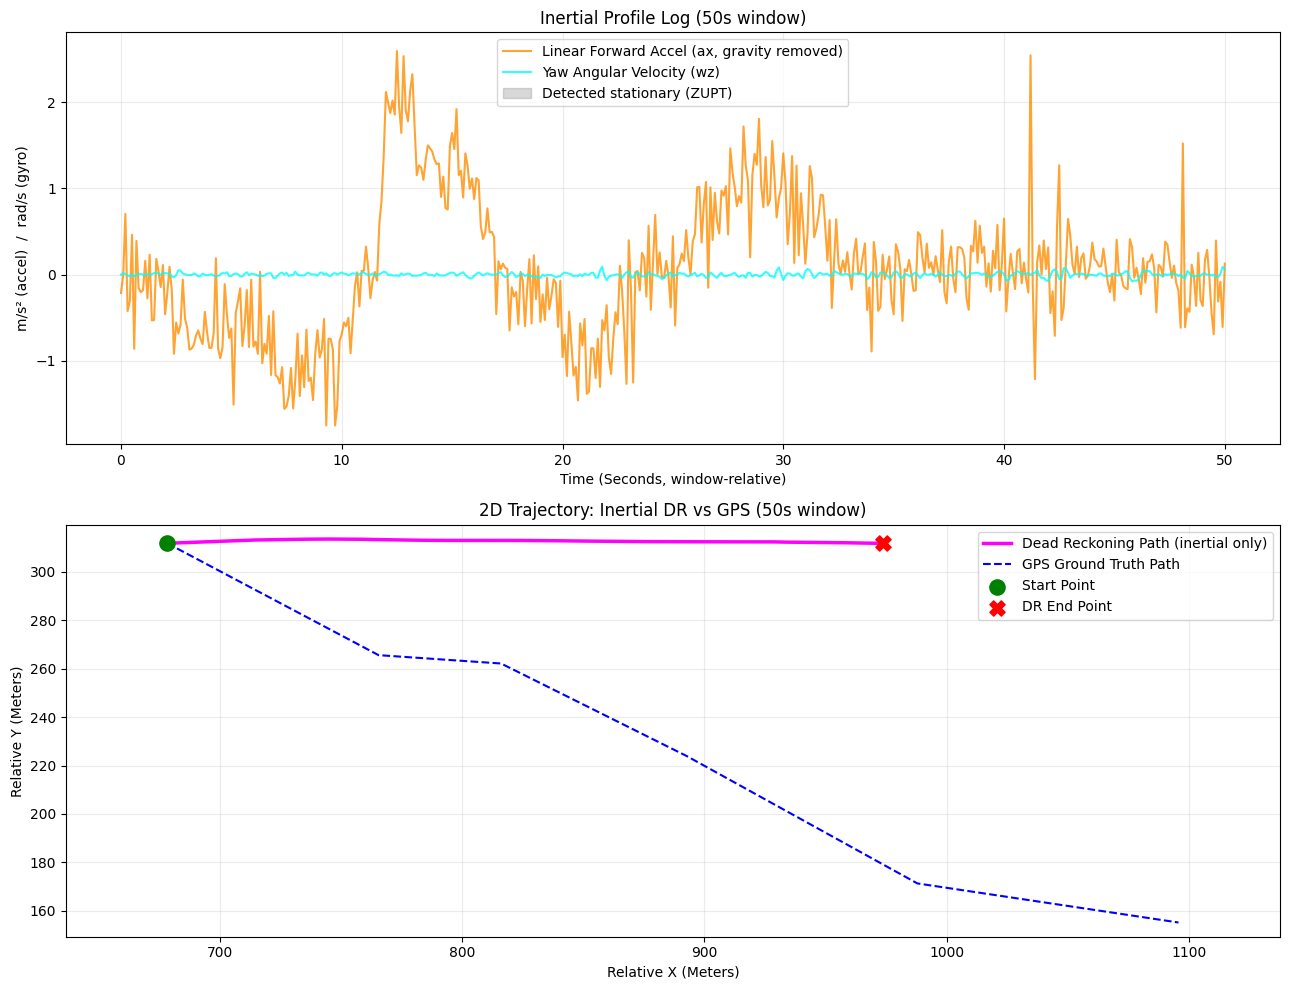


Error vs simulated outage duration (starting at t=100s):
    30s outage -> 149.7 m error
    60s outage -> 208.2 m error
    90s outage -> 229.8 m error


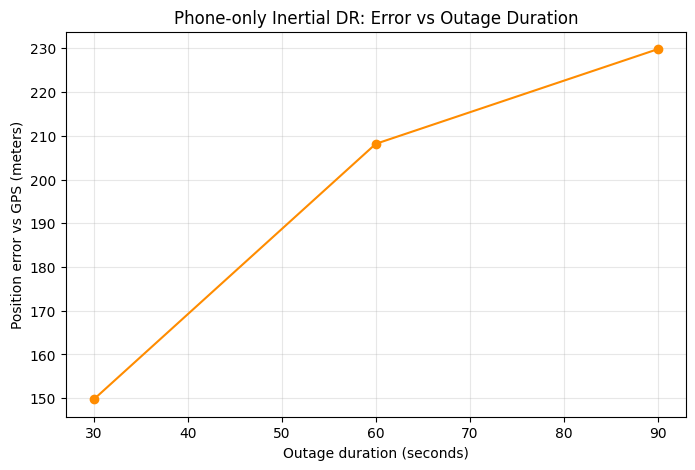

In [ ]:
import io
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import clear_output

clear_output(wait=True)

# -------------------------------------------------------------
# 0. CONFIG -- set your analysis window here
# -------------------------------------------------------------
# WINDOW_START_S / WINDOW_END_S define the "simulated GPS blackout"
# you're actually testing against -- keep this realistic (seconds to
# a couple minutes), not the whole drive. Full-drive DR error numbers
# look scary and aren't what you're claiming to solve.
WINDOW_START_S = 100
WINDOW_END_S = 150

# Also sweep a few durations from the same start point so you can show
# "error vs outage length" instead of one number -- this is the chart
# that actually answers "how long can this survive without GPS?"
DURATIONS_TO_TEST_S = [30, 60, 90]

# Stationary-detection threshold for ZUPT: if the rolling std of
# linear accel over STATIONARY_WINDOW_SAMPLES stays below this, treat
# the vehicle as stopped and pin speed to 0. Tune this against a
# stretch of data you know is a real stop (e.g. a traffic light).
STATIONARY_ACCEL_STD_THRESHOLD = 0.05
STATIONARY_WINDOW_SAMPLES = 10  # 1 second at 10 Hz

# -------------------------------------------------------------
# 1. FILE UPLOAD
# -------------------------------------------------------------
print("Please upload your IO-VNBD phone-side CSV file (S-*.csv).")
uploaded = files.upload()

if uploaded:
    filename = next(iter(uploaded))
    print(f"Uploaded file: {filename}\n")
else:
    print("Error: No file uploaded. Please re-run the cell and select a file.")
    sys.exit()

# -------------------------------------------------------------
# 2. DATA LOADING & COLUMN MAPPING
# -------------------------------------------------------------
def load_and_map_toolbox_data(file_buffer):
    df = pd.read_csv(io.BytesIO(file_buffer), encoding='latin1')
    df.columns = df.columns.str.strip()

    column_mapping = {
        'GPS LATITUDE (degrees)': 'lat',
        'GPS LONGITUDE (degrees)': 'lon',
        'GPS SPEED (Kmh)': 'gps_speed_kmh',
        'ACCELEROMETER X (m/s\u00b2)': 'ax_raw',
        'ACCELEROMETER Y (m/s\u00b2)': 'ay_raw',
        'ACCELEROMETER Z (m/s\u00b2)': 'az_raw',
        'GRAVITY X (m/s\u00b2)': 'gx',
        'GRAVITY Y (m/s\u00b2)': 'gy',
        'GRAVITY Z (m/s\u00b2)': 'gz',
        'GYROSCOPE Yaw (rad/s)': 'yaw_rate',
        'ORIENTATION (Yaw) (\u00b0)': 'compass_yaw',
    }
    df.rename(columns=column_mapping, inplace=True)
    return df

df = load_and_map_toolbox_data(uploaded[filename])

# -------------------------------------------------------------
# 3. FULL-RECORDING PREP (gravity removal, GPS frame, stationary flag)
# -------------------------------------------------------------
dt = 0.1  # 10 Hz sampling
df['t_sec'] = df.index * dt

df['ax'] = df['ax_raw'] - df['gx']
df['ay'] = df['ay_raw'] - df['gy']

# GPS ground-truth path over the FULL recording (needed to compute
# initial heading and to score error later, whatever window we pick).
R = 6371000
lat0, lon0 = np.radians(df['lat'].iloc[0]), np.radians(df['lon'].iloc[0])
df['gps_x'] = R * (np.radians(df['lon']) - lon0) * np.cos(lat0)
df['gps_y'] = R * (np.radians(df['lat']) - lat0)

# NEW: stationary detector via rolling std of linear accel -- this is
# the deployment-realistic version of ZUPT, since it only needs the
# phone's own sensors (no GPS required during an actual blackout).
df['ax_rolling_std'] = df['ax'].rolling(STATIONARY_WINDOW_SAMPLES, center=True).std()
df['is_stationary'] = df['ax_rolling_std'] < STATIONARY_ACCEL_STD_THRESHOLD
df['is_stationary'] = df['is_stationary'].fillna(False)


def run_dr_over_window(df, start_s, end_s):
    """Run inertial dead reckoning from start_s to end_s, re-zeroed at
    the window start, with heading aligned to the GPS bearing at that
    point and ZUPT applied using the stationary detector."""
    window = df[(df['t_sec'] >= start_s) & (df['t_sec'] <= end_s)].copy()
    if len(window) < 3:
        return None

    window = window.reset_index(drop=True)
    window['t_rel'] = window['t_sec'] - window['t_sec'].iloc[0]

    # FIX: align initial heading to the GPS bearing over the first
    # couple of fixes in the window, instead of assuming the vehicle
    # starts pointing along +X. This was silently rotating the whole
    # DR path relative to the GPS frame in the earlier version.
    gx0, gy0 = window['gps_x'].iloc[0], window['gps_y'].iloc[0]
    gx1, gy1 = window['gps_x'].iloc[min(3, len(window) - 1)], window['gps_y'].iloc[min(3, len(window) - 1)]
    initial_heading = np.arctan2(gy1 - gy0, gx1 - gx0)

    # Integrate speed from linear accel, with ZUPT resetting velocity
    # to 0 whenever the stationary detector fires.
    speed = np.zeros(len(window))
    v = 0.0
    for i in range(1, len(window)):
        step_dt = window['t_rel'].iloc[i] - window['t_rel'].iloc[i - 1]
        if window['is_stationary'].iloc[i]:
            v = 0.0
        else:
            v = max(0.0, v + window['ax'].iloc[i] * step_dt)
        speed[i] = v
    window['accel_speed_mps'] = speed

    window['heading_rad'] = initial_heading + (window['yaw_rate'] * dt).cumsum()
    window['delta_x'] = window['accel_speed_mps'] * np.cos(window['heading_rad']) * dt
    window['delta_y'] = window['accel_speed_mps'] * np.sin(window['heading_rad']) * dt
    window['dr_x'] = gx0 + window['delta_x'].cumsum()
    window['dr_y'] = gy0 + window['delta_y'].cumsum()

    error_m = np.sqrt(
        (window['dr_x'].iloc[-1] - window['gps_x'].iloc[-1]) ** 2
        + (window['dr_y'].iloc[-1] - window['gps_y'].iloc[-1]) ** 2
    )
    return window, error_m


# -------------------------------------------------------------
# 4. MAIN WINDOW -- the one you'll actually put on your slide
# -------------------------------------------------------------
result = run_dr_over_window(df, WINDOW_START_S, WINDOW_END_S)
if result is None:
    print("Window too short or out of range -- adjust WINDOW_START_S / WINDOW_END_S.")
    sys.exit()
window, main_error_m = result

print(f"Window: {WINDOW_START_S}s to {WINDOW_END_S}s ({WINDOW_END_S - WINDOW_START_S}s duration)")
print(f"Final position error vs GPS ground truth: {main_error_m:.1f} meters")

# -------------------------------------------------------------
# 5. VISUALIZATION (main window)
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

axes[0].plot(window['t_rel'], window['ax'], label='Linear Forward Accel (ax, gravity removed)', color='darkorange', alpha=0.8)
axes[0].plot(window['t_rel'], window['yaw_rate'], label='Yaw Angular Velocity (wz)', color='cyan', alpha=0.8)
axes[0].fill_between(window['t_rel'], -0.1, 0.1, where=window['is_stationary'], color='gray', alpha=0.3, label='Detected stationary (ZUPT)')
axes[0].set_title(f'Inertial Profile Log ({WINDOW_END_S - WINDOW_START_S}s window)')
axes[0].set_ylabel('m/s\u00b2 (accel)  /  rad/s (gyro)')
axes[0].set_xlabel('Time (Seconds, window-relative)')
axes[0].legend()
axes[0].grid(True, alpha=0.25)

axes[1].plot(window['dr_x'], window['dr_y'], label='Dead Reckoning Path (inertial only)', color='magenta', linewidth=2.5)
axes[1].plot(window['gps_x'], window['gps_y'], label='GPS Ground Truth Path', color='blue', linestyle='--', linewidth=1.5)
axes[1].scatter(window['dr_x'].iloc[0], window['dr_y'].iloc[0], color='green', marker='o', s=120, label='Start Point', zorder=5)
axes[1].scatter(window['dr_x'].iloc[-1], window['dr_y'].iloc[-1], color='red', marker='X', s=120, label='DR End Point', zorder=5)
axes[1].set_title(f'2D Trajectory: Inertial DR vs GPS ({WINDOW_END_S - WINDOW_START_S}s window)')
axes[1].set_xlabel('Relative X (Meters)')
axes[1].set_ylabel('Relative Y (Meters)')
axes[1].axis('equal')
axes[1].legend()
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 6. ERROR VS OUTAGE DURATION -- this is the chart for Slide 6
# -------------------------------------------------------------
durations_results = []
for dur in DURATIONS_TO_TEST_S:
    r = run_dr_over_window(df, WINDOW_START_S, WINDOW_START_S + dur)
    if r is not None:
        durations_results.append((dur, r[1]))

print("\nError vs simulated outage duration (starting at t=%ds):" % WINDOW_START_S)
for dur, err in durations_results:
    print(f"  {dur:>4}s outage -> {err:.1f} m error")

if durations_results:
    plt.figure(figsize=(8, 5))
    plt.plot([d for d, _ in durations_results], [e for _, e in durations_results], marker='o', color='darkorange')
    plt.title('Phone-only Inertial DR: Error vs Outage Duration')
    plt.xlabel('Outage duration (seconds)')
    plt.ylabel('Position error vs GPS (meters)')
    plt.grid(alpha=0.3)
    plt.show()